========================================================

EDA synthetic_energy_emissions_dataset.csv

In [1]:
import pandas as pd

In [10]:
url = 'https://raw.githubusercontent.com/carbon-footprint-analysis/carbon-footprint-analysis/refs/heads/main/data/processed/synthetic_energy_emissions_dataset.csv'
raw = pd.read_csv(url).drop(columns=["Unnamed: 0"])

In [11]:
raw

,company_id,date,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission
0,C320336,2025-09-02,PA,industrial,small,eletrico,28128.011264,hydro,562.560225
1,C535112,2025-02-20,SP,outros,medium,eletrico,5244.043607,nuclear,52.440436
2,C935768,2025-06-27,GO,industrial,large,eletrico,55612.924196,wind,556.129242
3,C580793,2025-12-08,PR,outros,small,eletrico,11322.965762,thermal,6793.779457
4,C283829,2025-12-08,RJ,industrial,large,eletrico,103544.415383,hydro,2070.888308
...,...,...,...,...,...,...,...,...,...
99995,C220240,2025-01-26,RJ,industrial,medium,eletrico,33254.657106,hydro,665.093142
99996,C454466,2025-01-20,SP,residencial,small,eletrico,122.172298,hydro,2.443446
99997,C243172,2025-06-14,PI,rural,small,eletrico,770.441846,solar,15.408837
99998,C716973,2025-02-21,SP,industrial,medium,eletrico,18448.646133,hydro,368.972923


In [12]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   company_id     100000 non-null  object 
 1   date           100000 non-null  object 
 2   state          100000 non-null  object 
 3   usage_type     100000 non-null  object 
 4   company_size   100000 non-null  object 
 5   fuel_type      100000 non-null  object 
 6   energy_kwh     100000 non-null  float64
 7   energy_source  100000 non-null  object 
 8   co2_emission   100000 non-null  float64
dtypes: float64(2), object(7)
memory usage: 6.9+ MB


Tipagem das colunas
| coluna        | tipo ideal |
| ------------- | ---------- |
| company_id    | category   |
| date          | datetime   |
| state         | category   |
| usage_type    | category   |
| company_size  | category   |
| fuel_type     | category   |
| energy_kwh    | float      |
| energy_source | category   |
| co2_emission  | float      |


In [13]:
raw["date"] = pd.to_datetime(raw["date"])

categorical_cols = [
"company_id",
"state",
"usage_type",
"company_size",
"fuel_type",
"energy_source"
]

for col in categorical_cols:
    raw[col] = raw[col].astype("category")

In [14]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   company_id     100000 non-null  category      
 1   date           100000 non-null  datetime64[ns]
 2   state          100000 non-null  category      
 3   usage_type     100000 non-null  category      
 4   company_size   100000 non-null  category      
 5   fuel_type      100000 non-null  category      
 6   energy_kwh     100000 non-null  float64       
 7   energy_source  100000 non-null  category      
 8   co2_emission   100000 non-null  float64       
dtypes: category(6), datetime64[ns](1), float64(2)
memory usage: 5.9 MB


ETL leve

add região

In [19]:
region_map = {
"RS":"sul","SC":"sul","PR":"sul",
"SP":"sudeste","RJ":"sudeste","MG":"sudeste","ES":"sudeste",
"GO":"centro-oeste","MT":"centro-oeste","MS":"centro-oeste","DF":"centro-oeste",
"BA":"nordeste","PE":"nordeste","CE":"nordeste","RN":"nordeste","PB":"nordeste","AL":"nordeste","SE":"nordeste","MA":"nordeste","PI":"nordeste",
"AM":"norte","PA":"norte","AC":"norte","RO":"norte","RR":"norte","AP":"norte","TO":"norte"
}

raw["region"] = raw["state"].map(region_map)

add mes

In [20]:
raw["month"] = raw["date"].dt.month

add estação

In [21]:
def season(m):
    if m in [12,1,2]:
        return "verao"
    if m in [3,4,5]:
        return "outono"
    if m in [6,7,8]:
        return "inverno"
    return "primavera"

raw["season"] = raw["month"].apply(season)

add qtd de carbono pro kwh (medir se energia é limpa)

In [22]:
raw["carbon_intensity"] = raw["co2_emission"] / raw["energy_kwh"]

apagar coluna data, os dias foram gerados de maneira que não agregam nada inclusive acontece o contrario porque os dados que tivemos para gerar sinteticamente tem como variavel temporal o mes !

In [26]:
raw = raw.drop(columns=["date"])

KeyError: "['date'] not found in axis"

In [25]:
raw.head()

,company_id,state,usage_type,company_size,fuel_type,energy_kwh,energy_source,co2_emission,region,month,season,carbon_intensity
0,C320336,PA,industrial,small,eletrico,28128.011264,hydro,562.560225,norte,9,primavera,0.02
1,C535112,SP,outros,medium,eletrico,5244.043607,nuclear,52.440436,sudeste,2,verao,0.01
2,C935768,GO,industrial,large,eletrico,55612.924196,wind,556.129242,centro-oeste,6,inverno,0.01
3,C580793,PR,outros,small,eletrico,11322.965762,thermal,6793.779457,sul,12,verao,0.60
4,C283829,RJ,industrial,large,eletrico,103544.415383,hydro,2070.888308,sudeste,12,verao,0.02


EDA

Distribuições

tipo de uso

In [ ]:
raw["usage_type"].value_counts()

,count
usage_type,
industrial,38971
residencial,28076
comercial,17548
outros,9972
rural,5433


fonte energia

In [ ]:
raw["energy_source"].value_counts()

,count
energy_source,
hydro,51642
thermal,22823
wind,15818
solar,8785
nuclear,932


estatisticas de consumo

In [ ]:
raw["energy_kwh"].describe()

,energy_kwh
count,100000.000000
mean,18000.268397
std,27591.054986
min,53.226406
25%,257.970756
50%,2460.300833
75%,29479.602710
max,367659.792448


consumo por setor

In [27]:
raw.groupby("usage_type")["energy_kwh"].mean().sort_values()

/tmp/ipykernel_9402/4226823955.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("usage_type")["energy_kwh"].mean().sort_values()


,energy_kwh
usage_type,
residencial,186.751154
rural,712.025744
comercial,1495.234719
outros,5178.497525
industrial,43956.706841


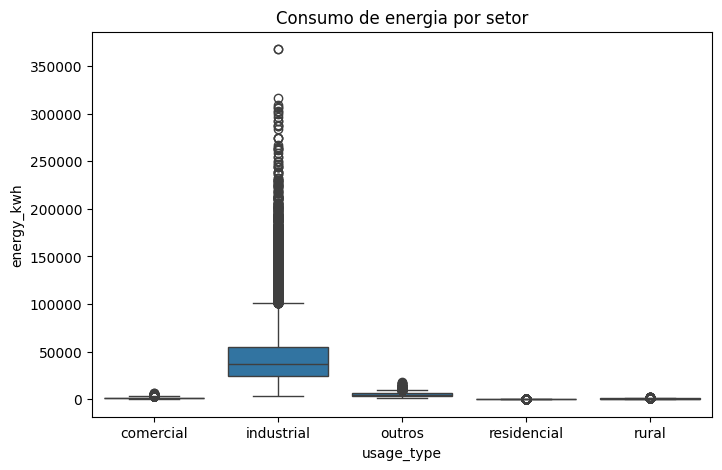

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(data=raw, x="usage_type", y="energy_kwh")
plt.title("Consumo de energia por setor")
plt.show()

emissão  co² por fonte de energia

In [28]:
raw.groupby("energy_source")["co2_emission"].mean().sort_values()

/tmp/ipykernel_9402/1220726412.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("energy_source")["co2_emission"].mean().sort_values()


,co2_emission
energy_source,
nuclear,171.798267
wind,178.111832
solar,361.247412
hydro,363.080098
thermal,10675.833119


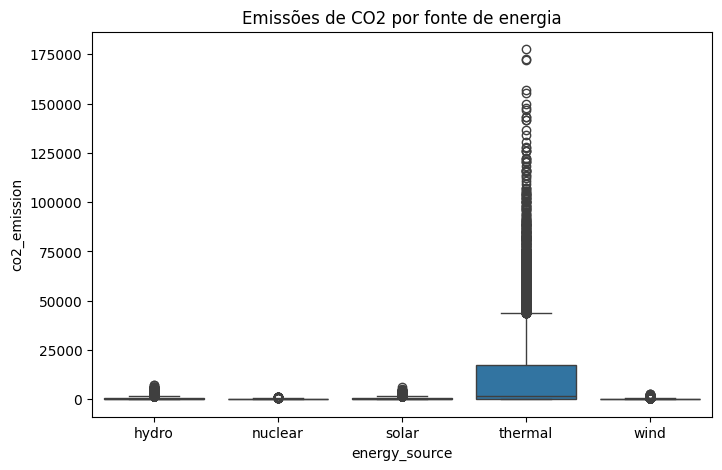

In [43]:
plt.figure(figsize=(8,5))
sns.boxplot(data=raw, x="energy_source", y="co2_emission")
plt.title("Emissões de CO2 por fonte de energia")
plt.show()

emissão co²| por região

In [29]:
raw.groupby("region")["co2_emission"].mean().sort_values()

,co2_emission
region,
centro-oeste,1983.933088
nordeste,2257.656646
sul,2700.217385
sudeste,2854.219094
norte,3228.845311


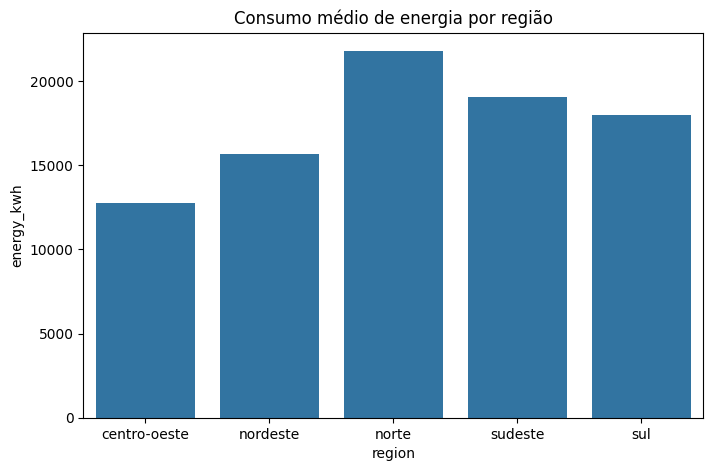

In [44]:
region_energy = raw.groupby("region")["energy_kwh"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=region_energy, x="region", y="energy_kwh")
plt.title("Consumo médio de energia por região")
plt.show()

emissão por estação

In [30]:
raw.groupby("season")["co2_emission"].mean().sort_values()

,co2_emission
season,
outono,2642.692658
inverno,2664.720117
verao,2691.889983
primavera,2742.865847


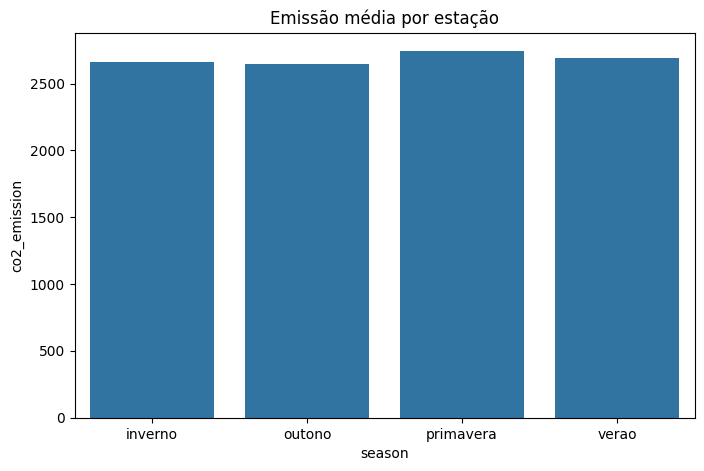

In [45]:
season_emission = raw.groupby("season")["co2_emission"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=season_emission, x="season", y="co2_emission")
plt.title("Emissão média por estação")
plt.show()

intensidade de carbono por fonte

In [31]:
raw.groupby("energy_source")["carbon_intensity"].mean()

/tmp/ipykernel_9402/1116575236.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  raw.groupby("energy_source")["carbon_intensity"].mean()


,carbon_intensity
energy_source,
hydro,0.02
nuclear,0.01
solar,0.02
thermal,0.60
wind,0.01


/tmp/ipykernel_9402/4169981311.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  carbon_source = raw.groupby("energy_source")["carbon_intensity"].mean().reset_index()


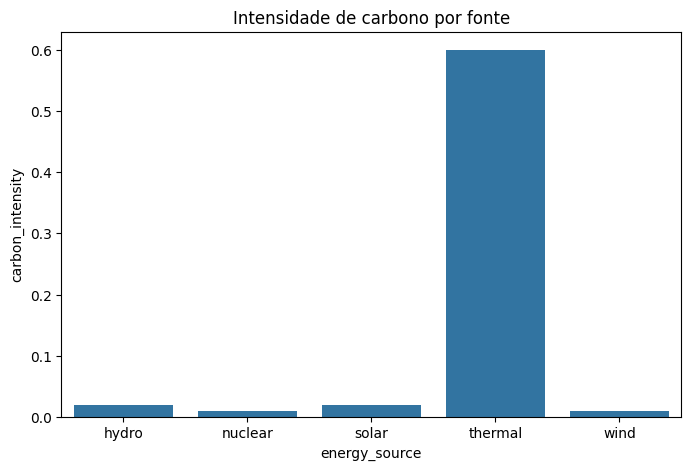

In [46]:
carbon_source = raw.groupby("energy_source")["carbon_intensity"].mean().reset_index()

plt.figure(figsize=(8,5))
sns.barplot(data=carbon_source, x="energy_source", y="carbon_intensity")
plt.title("Intensidade de carbono por fonte")
plt.show()

carbono por fonte

correlação entre energia x emissão

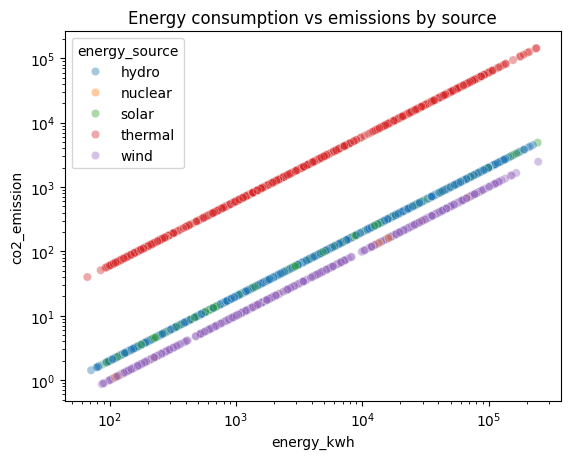

In [48]:
sample = raw.sample(5000)

sns.scatterplot(
    data=sample,
    x="energy_kwh",
    y="co2_emission",
    hue="energy_source",
    alpha=0.4
)

plt.xscale("log")
plt.yscale("log")

plt.title("Energy consumption vs emissions by source")
plt.show()